In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

torch.__version__

'2.11.0+cu128'

In [3]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
train_spilt = int(0.8 * len(X))
X_train,y_train = X[:train_spilt],y[:train_spilt]
X_test,y_test = X[train_spilt:],y[train_spilt:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(10,7))

    plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")

    plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

    if predictions is not None:
        plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

    plt.legend(prop={"size":14});

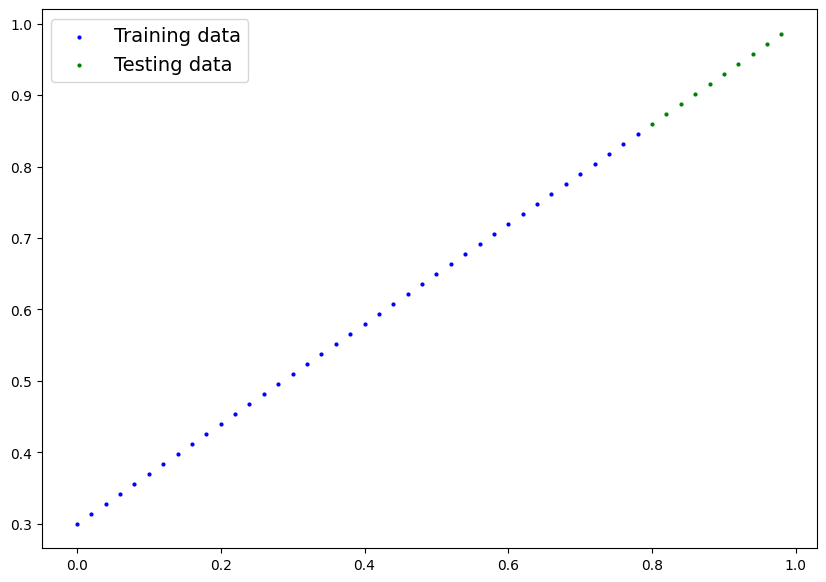

In [6]:
plot_predictions();

In [7]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True) # required_grad的意思是我们可以用梯度下降去优化

    def forward(self,x:torch.Tensor):
        return self.weights * x + self.bias

In [8]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
#Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

In [11]:
print(f"Number of testing examples:{len(X_test)}")
print(f"Number of predictions made:{len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing examples:10
Number of predictions made:10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


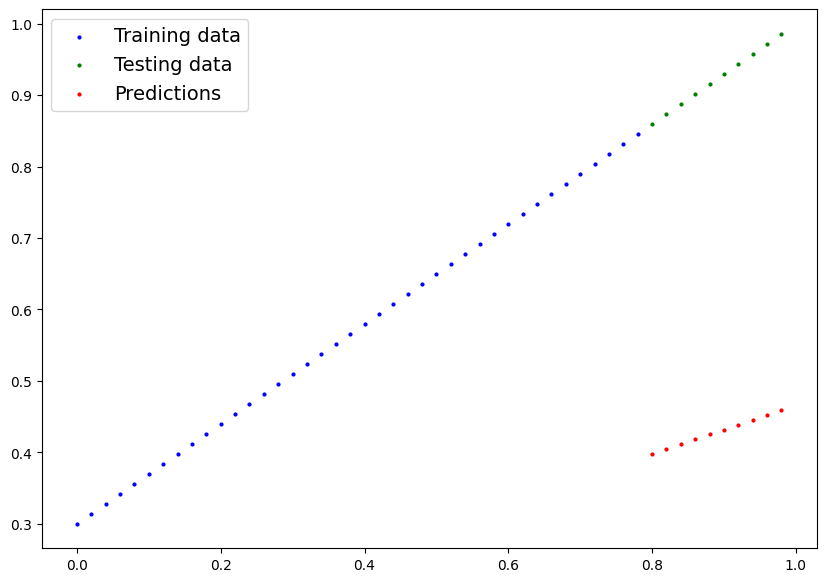

In [12]:
plot_predictions(predictions=y_preds)

In [13]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

In [14]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(model_0.parameters(),lr=0.01)

In [15]:
torch.manual_seed(20)

epochs = 1000

train_loss_values = []
test_loss_values = []
epoch_counts = []

for epoch in range(epochs):
    ###Training

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()
    ###Testing
    with torch.inference_mode():
        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred,y_test.type(torch.float))

        if epoch%10 == 0:
            epoch_counts.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch:{epoch} | MAE Train Loss:{loss} | MAE Test Loss:{test_loss}")

Epoch:0 | MAE Train Loss:0.31288138031959534 | MAE Test Loss:0.48106518387794495
Epoch:10 | MAE Train Loss:0.1976713240146637 | MAE Test Loss:0.3463551998138428
Epoch:20 | MAE Train Loss:0.08908725529909134 | MAE Test Loss:0.21729660034179688
Epoch:30 | MAE Train Loss:0.053148526698350906 | MAE Test Loss:0.14464017748832703
Epoch:40 | MAE Train Loss:0.04543796554207802 | MAE Test Loss:0.11360953003168106
Epoch:50 | MAE Train Loss:0.04167863354086876 | MAE Test Loss:0.09919948130846024
Epoch:60 | MAE Train Loss:0.03818932920694351 | MAE Test Loss:0.08886633068323135
Epoch:70 | MAE Train Loss:0.03476089984178543 | MAE Test Loss:0.0805937647819519
Epoch:80 | MAE Train Loss:0.03132382780313492 | MAE Test Loss:0.07232122868299484
Epoch:90 | MAE Train Loss:0.02788739837706089 | MAE Test Loss:0.06473556160926819
Epoch:100 | MAE Train Loss:0.024458957836031914 | MAE Test Loss:0.05646304413676262
Epoch:110 | MAE Train Loss:0.021020207554101944 | MAE Test Loss:0.04819049686193466
Epoch:120 | MAE

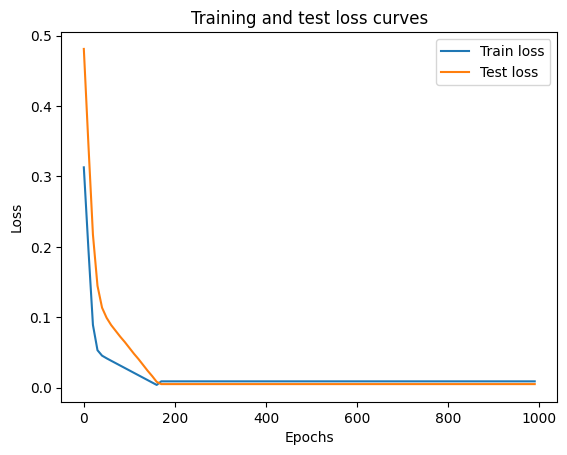

In [16]:
# Plot the loss curves
plt.plot(epoch_counts, train_loss_values, label="Train loss")
plt.plot(epoch_counts, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [17]:
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights:{weight},bias:{bias}")

The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

And the original values for weights and bias are:
weights:0.7,bias:0.3


In [18]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to:{MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to:models\01_pytorch_workflow_model_0.pth


In [19]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

'ls' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [20]:
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [21]:
loaded_model_0.eval()

with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

In [22]:
y_preds == loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [23]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cu128'

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device:{device}")

Using device:cuda


In [25]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [26]:
train_split = int(len(X)*0.8)
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:] 

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

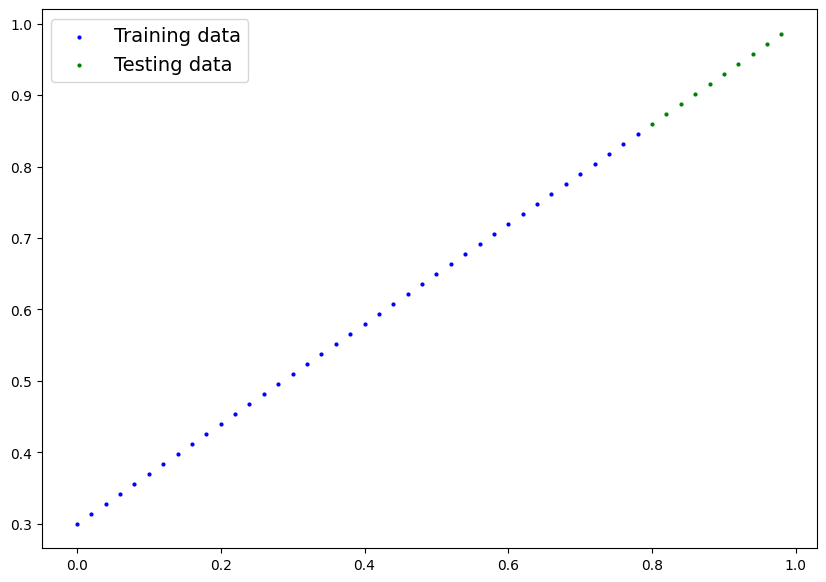

In [27]:
plot_predictions(X_train,y_train,X_test,y_test)

In [28]:
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1,out_features=1)


    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1,model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [30]:
next(model_1.parameters()).device

device(type='cpu')

In [31]:
model_1.to(device)
next(model_1.parameters()).device 

device(type='cuda', index=0)

In [32]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [33]:
torch.manual_seed(42)

epochs = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    y_pred = model_1(X_train)

    loss = loss_fn(y_pred,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_1.eval()

    with torch.inference_mode():
        test_pred = model_1(X_test)

        test_loss = loss_fn(test_pred,y_test)

    if epoch % 10 == 0:
        print(f"Epoch :{epoch} | Train Loss:{loss} | Test loss:{test_loss}")

Epoch :0 | Train Loss:0.5551779270172119 | Test loss:0.5739762187004089
Epoch :10 | Train Loss:0.4399681091308594 | Test loss:0.4392664134502411
Epoch :20 | Train Loss:0.3247582018375397 | Test loss:0.30455657839775085
Epoch :30 | Train Loss:0.20954833924770355 | Test loss:0.16984669864177704
Epoch :40 | Train Loss:0.09433844685554504 | Test loss:0.03513690456748009
Epoch :50 | Train Loss:0.023886388167738914 | Test loss:0.04784907028079033
Epoch :60 | Train Loss:0.019956795498728752 | Test loss:0.045803118497133255
Epoch :70 | Train Loss:0.016517987474799156 | Test loss:0.037530567497015
Epoch :80 | Train Loss:0.013089174404740334 | Test loss:0.02994490973651409
Epoch :90 | Train Loss:0.009653178043663502 | Test loss:0.02167237363755703
Epoch :100 | Train Loss:0.006215683650225401 | Test loss:0.014086711220443249
Epoch :110 | Train Loss:0.00278724217787385 | Test loss:0.005814164876937866
Epoch :120 | Train Loss:0.0012645035749301314 | Test loss:0.013801801018416882
Epoch :130 | Train

In [34]:
from pprint import pprint
print("The model learned the following values for weight and bias:")
pprint(model_1.state_dict())
print("\nAnd the original values for weights amd bias are:")
print(f"weights:{weight},bias:{bias}")


The model learned the following values for weight and bias:
OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

And the original values for weights amd bias are:
weights:0.7,bias:0.3


In [35]:
model_1.eval()

with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

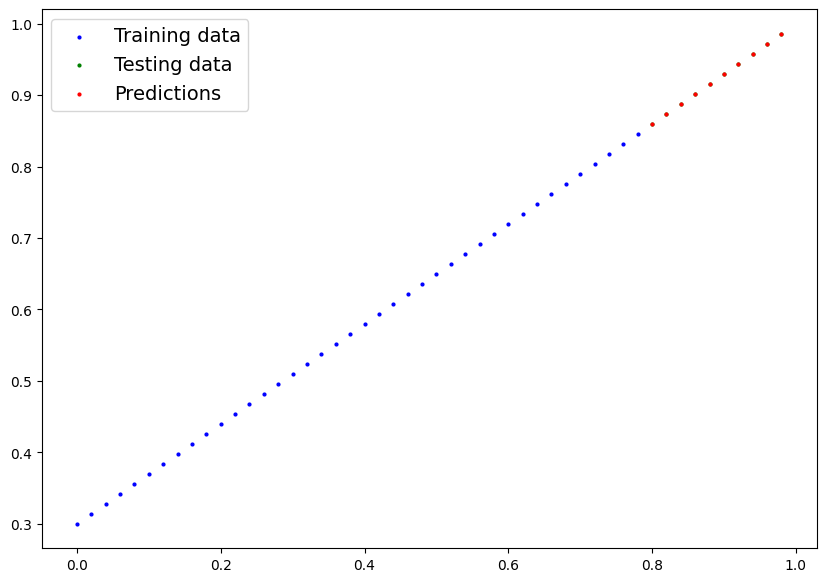

In [36]:
plot_predictions(predictions=y_preds.cpu())

In [37]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving models to:{MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving models to:models\01_pytorch_workflow_model_1.pth


In [38]:
loaded_model_1 = LinearRegressionModelV2()

loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

loaded_model_1.to(device)

print(f"Loaded Model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded Model:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
cuda:0


In [39]:
loaded_model_1.eval()

with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
loaded_model_1_preds == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')